<>:252: SyntaxWarning: invalid escape sequence '\e'
<>:252: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1627/1819286881.py:252: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('Collisional energy loss per pair ($\epsilon_L$)'); ax.grid(True, alpha=0.3)


  0D Global Model — Argon Discharge (Self-Consistent)
  Lee & Lieberman, JVST A 13, 368 (1995)
Reactor dimensions: L=30.00 cm, R=15.00 cm
Volume = 21205.8 cm^3, Wall area = 4241.2 cm^2

[1] Executing self-consistent pressure scan...
   p [mTorr]     Te [eV]      ne [cm^-3]      n* [cm^-3]    eps_L [eV]
----------------------------------------------------------------------
        0.10      11.542       6.644e+10       4.200e+10         16.33
        0.29       6.096       1.520e+11       4.758e+10         16.13
        0.86       4.219       2.523e+11       5.312e+10         16.04
        2.54       3.173       4.315e+11       5.333e+10         15.97
        7.47       2.489       8.478e+11       4.585e+10         16.07
       21.97       2.028       1.761e+12       3.581e+10         16.96
       64.58       1.708       3.275e+12       2.701e+10         21.44
      189.88       1.473       4.062e+12       1.987e+10         44.07


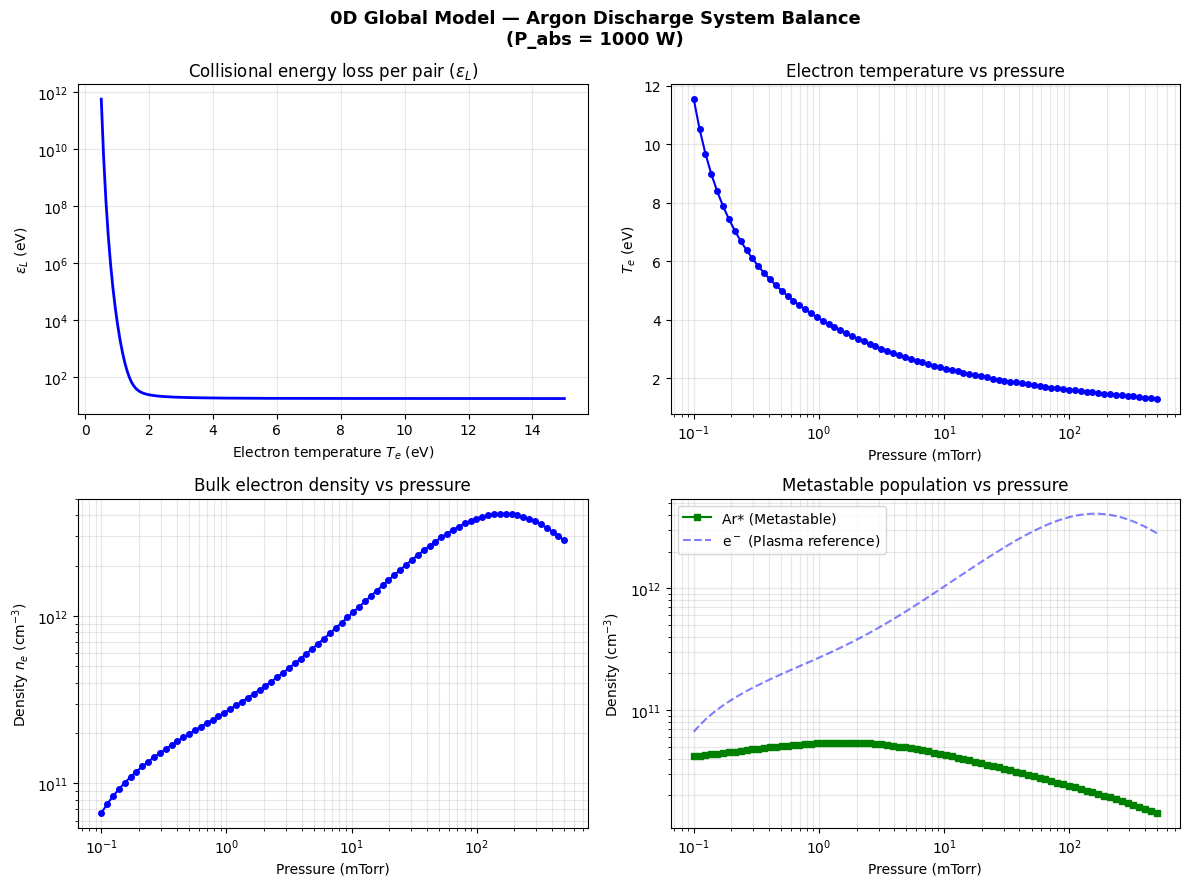


[2] Executing power scan profile at 5 mTorr...


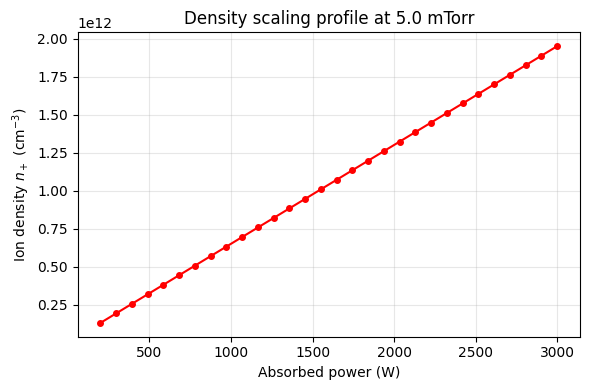


All tasks finalized. Plots generated cleanly.


In [1]:
"""
=============================================================================
  0D Global Model for Argon High-Density Plasma Discharge
  Based on: Lee & Lieberman, J. Vac. Sci. Technol. A 13, 368 (1995)
=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.constants import e, k, m_e, m_u, pi

# ============================================================
# CONSTANTS & REACTOR GEOMETRY
# ============================================================
e_charge = e          # elementary charge [C]
kB       = k          # Boltzmann constant [J/K]
M_Ar     = 39.948 * m_u   # Argon mass [kg]

# Reactor geometry (Cylindrical TCP reactor)
L = 0.30             # chamber length [m]
R = 0.15           # chamber radius [m]
V = pi * R**2 * L     # reactor volume [m^3]
A_total = 2*pi*R*L + 2*pi*R**2   # total physical wall area [m^2]

print("=" * 60)
print("  0D Global Model — Argon Discharge (Self-Consistent)")
print("  Lee & Lieberman, JVST A 13, 368 (1995)")
print("=" * 60)
print(f"Reactor dimensions: L={L*100:.2f} cm, R={R*100:.2f} cm")
print(f"Volume = {V*1e6:.1f} cm^3, Wall area = {A_total*1e4:.1f} cm^2\n")


# ============================================================
# PHYSICS UTILITIES & RATE COEFFICIENTS
# ============================================================
def rate_coefficients(Te):
    """Compute rate coefficients [m^3/s] as functions of Te [eV]."""
    k1 = 1.23e-7 * np.exp(-18.68 / Te)          # direct ionization
    k2 = 3.71e-8 * np.exp(-15.06 / Te)          # excitation to Ar*
    k3 = 2.05e-7 * np.exp(-4.95  / Te)          # step ionization
    k4 = 2.0e-7                                 # superelastic quenching
    k5 = 6.2e-10                                # metastable pooling

    # Convert from cm^3/s to m^3/s
    return (k1*1e-6, k2*1e-6, k3*1e-6, k4*1e-6, k5*1e-6)

def bohm_velocity(Te):
    """Bohm velocity uB = sqrt(e*Te / M_Ar) [m/s]."""
    return np.sqrt(e_charge * Te / M_Ar)

def neutral_density(pressure_mTorr):
    """Total ground state gas density from ideal gas law at T_n = 600 K."""
    T_neutral = 600.0
    pressure_Pa = pressure_mTorr * 0.1333
    return pressure_Pa / (kB * T_neutral)

def mean_free_path(pressure_mTorr):
    """Ion-neutral mean-free path lambda [m]."""
    n_gas = neutral_density(pressure_mTorr)
    sigma = 3.67e-19           # Ar-Ar collision cross section [m^2]
    return 1.0 / (np.sqrt(2) * sigma * n_gas)

def geometry_factors(Te, pressure_mTorr, Ti_eV=0.05):
    """Compute axial (h_L) and radial (h_R) sheath-edge ratios (Eqs. 13-14)."""
    lam  = mean_free_path(pressure_mTorr)
    uB   = bohm_velocity(Te)
    g    = Te / Ti_eV

    nu_in = uB / lam if lam > 0 else 1e10
    Da    = (e_charge * Te) / (M_Ar * nu_in)

    # Axial profile
    term_axial  = (0.86 * L * uB / (pi * Da))**2
    hL = 0.86 / np.sqrt(3 + L / (2 * lam) + term_axial)

    # Radial profile
    J1_2405 = 0.5191
    term_rad  = (0.8 * R * uB / (2.405 * J1_2405 * g * Da))**2
    hR = 0.8  / np.sqrt(4 + R / lam + term_rad)

    return hL, hR

def effective_area(Te, pressure_mTorr):
    """Compute loss-weighted area Aeff."""
    hL, hR = geometry_factors(Te, pressure_mTorr)
    Aeff = hL * 2 * pi * R**2 + hR * 2 * pi * R * L
    return Aeff, hL, hR


# ============================================================
# COMPONENT RESOLUTION (METASTABLES & ENERGY LOSS)
# ============================================================
def metastable_density(Te, ne, pressure_mTorr):
    """Solve the quadratic particle balance for Ar* density [m^-3]."""
    k1, k2, k3, k4, k5 = rate_coefficients(Te)
    n_Ar = neutral_density(pressure_mTorr)

    Lambda2_inv = (pi/L)**2 + (2.405/R)**2
    T_neutral = 600.0
    v_th = np.sqrt(8 * kB * T_neutral / (pi * M_Ar))
    DKN  = v_th / (3 * np.sqrt(Lambda2_inv))
    sigma_Ar = 3.67e-19
    DAA  = (3/16) * (1/(n_Ar * sigma_Ar)) * np.sqrt(pi * kB * T_neutral / M_Ar)
    Deff = 1.0 / (1.0/DAA + 1.0/DKN) if (DAA > 0 and DKN > 0) else min(DAA, DKN)

    loss_rate = ne * (k3 + k4) + Deff * Lambda2_inv

    a = k5
    b = loss_rate
    c = -ne * k2 * n_Ar

    discriminant = b**2 - 4*a*c
    if discriminant < 0:
        return 0.0
    return max((-b + np.sqrt(discriminant)) / (2*a), 0.0)

def energy_loss_per_pair(Te, n_star, ne, pressure_mTorr):
    """Compute collisional energy loss per electron-ion pair, epsilon_L [eV]."""
    k1, k2, k3, k4, k5 = rate_coefficients(Te)
    n_Ar = neutral_density(pressure_mTorr)

    epsilon_iz  = 15.76
    epsilon_iz3 = 4.20
    epsilon_exc = 11.56

    k_el = 2.0e-13
    epsilon_el = 3.0 * (m_e / M_Ar) * Te

    nu_iz1 = k1 * n_Ar
    nu_iz3 = k3 * n_star
    nu_iz_total = nu_iz1 + nu_iz3

    nu_exc = k2 * n_Ar
    nu_el = k_el * n_Ar
    nu_q   = k4 * n_star

    e_gain = (nu_q / nu_iz_total) * epsilon_exc if nu_iz_total > 0 else 0.0

    if nu_iz_total <= 0:
        return 100.0

    eps_L = (
        (nu_iz1 / nu_iz_total) * epsilon_iz
      + (nu_iz3 / nu_iz_total) * epsilon_iz3
      + (nu_exc / nu_iz_total) * epsilon_exc
      + (nu_el  / nu_iz_total) * epsilon_el
      - e_gain
    )
    return max(eps_L, 1.0)


# ============================================================
# CORE BALANCES & SOLVER ENGINE
# ============================================================
def solve_density(Te, pressure_mTorr, P_abs_W):
    """Solves the volume-integrated power balance equation for bulk density ne."""
    uB   = bohm_velocity(Te)
    _, hL, hR = effective_area(Te, pressure_mTorr)
    n_star = metastable_density(Te, 1e16, pressure_mTorr) # baseline estimation
    eps_L  = energy_loss_per_pair(Te, n_star, 1e16, pressure_mTorr)

    epsilon_iw = 5.0 * Te    # Kinetic ion loss energy
    epsilon_ew = 2.0 * Te    # Kinetic electron loss energy
    epsilon_T = eps_L + epsilon_iw + epsilon_ew

    # Fix Bug 1: Track distinct hL/hR loss pathways explicitly
    power_loss_factor = (hL * 2 * pi * R**2 + hR * 2 * pi * R * L) * uB * epsilon_T * e_charge
    return P_abs_W / power_loss_factor

def solve_system_self_consistent(pressure_mTorr, P_abs_W, max_iter=30, tol=1e-4):
    """Fix Bug 2: Coupled relaxation solver mapping Te and ne sequentially."""
    ne_guess = 1e16  # starting bulk density (m^-3)
    Te_guess = 3.0   # starting electron temperature (eV)

    for _ in range(max_iter):
        ne_old = ne_guess

        # Inner particle balance optimization function
        def particle_residual(T):
            k1, _, k3, _, _ = rate_coefficients(T)
            n_Ar = neutral_density(pressure_mTorr)
            uB = bohm_velocity(T)
            Aeff, _, _ = effective_area(T, pressure_mTorr)
            n_star = metastable_density(T, ne_guess, pressure_mTorr)

            return V * (k1 * n_Ar + k3 * n_star) - Aeff * uB

        try:
            Te_guess = brentq(particle_residual, 0.4, 25.0, xtol=1e-5)
        except ValueError:
            pass # keep prior temperature trajectory point if limits hit boundary

        ne_guess = solve_density(Te_guess, pressure_mTorr, P_abs_W)

        if abs(ne_guess - ne_old) / ne_old < tol:
            break

    return Te_guess, ne_guess


# ============================================================
# EXPERIMENT EXECUTION PIPELINES
# ============================================================
def run_pressure_sweep(P_abs_W=1000.0):
    pressures_mTorr = np.logspace(-1, 2.7, 80) # 0.1 to ~500 mTorr

    results = {
        'p': pressures_mTorr, 'Te': np.zeros_like(pressures_mTorr),
        'ne': np.zeros_like(pressures_mTorr), 'n_star': np.zeros_like(pressures_mTorr),
        'eps_L': np.zeros_like(pressures_mTorr), 'hL': np.zeros_like(pressures_mTorr),
        'hR': np.zeros_like(pressures_mTorr)
    }

    print(f"{'p [mTorr]':>12}  {'Te [eV]':>10}  {'ne [cm^-3]':>14}  {'n* [cm^-3]':>14}  {'eps_L [eV]':>12}")
    print("-" * 70)

    for i, p in enumerate(pressures_mTorr):
        Te, ne = solve_system_self_consistent(p, P_abs_W)
        if np.isnan(Te) or ne <= 0:
            continue

        n_star = metastable_density(Te, ne, p)
        eps_L  = energy_loss_per_pair(Te, n_star, ne, p)
        _, hL, hR = effective_area(Te, p)

        results['Te'][i] = Te
        results['ne'][i] = ne
        results['n_star'][i] = n_star
        results['eps_L'][i] = eps_L
        results['hL'][i] = hL
        results['hR'][i] = hR

        if i % 10 == 0:
            print(f"  {p:10.2f}  {Te:10.3f}  {ne*1e-6:14.3e}  {n_star*1e-6:14.3e}  {eps_L:12.2f}")

    return results

def plot_results(results, P_abs_W=1000.0):
    p, Te, ne, n_star, eps_L = results['p'], results['Te'], results['ne'], results['n_star'], results['eps_L']
    valid = (Te > 0) & (ne > 0)
    p, Te, ne, n_star, eps_L = [arr[valid] for arr in [p, Te, ne, n_star, eps_L]]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f'0D Global Model — Argon Discharge System Balance\n(P_abs = {P_abs_W:.0f} W)', fontsize=13, fontweight='bold')

    # Panel 1: eps_L Curve
    ax = axes[0, 0]
    Te_range = np.linspace(0.5, 15, 200)
    ax.semilogy(Te_range, [energy_loss_per_pair(Tv, metastable_density(Tv, 1e16, 5.0), 1e16, 5.0) for Tv in Te_range], 'b-', lw=2)
    ax.set_xlabel('Electron temperature $T_e$ (eV)'); ax.set_ylabel('$\\epsilon_L$ (eV)')
    ax.set_title('Collisional energy loss per pair ($\epsilon_L$)'); ax.grid(True, alpha=0.3)

    # Panel 2: Te vs Pressure
    ax = axes[0, 1]
    ax.semilogx(p, Te, 'b-o', ms=4, lw=1.5)
    ax.set_xlabel('Pressure (mTorr)'); ax.set_ylabel('$T_e$ (eV)')
    ax.set_title('Electron temperature vs pressure'); ax.grid(True, alpha=0.3, which='both')

    # Panel 3: Plasma Density vs Pressure
    ax = axes[1, 0]
    ax.loglog(p, ne*1e-6, 'b-o', ms=4, lw=1.5)
    ax.set_xlabel('Pressure (mTorr)'); ax.set_ylabel('Density $n_e$ (cm$^{-3}$)')
    ax.set_title('Bulk electron density vs pressure'); ax.grid(True, alpha=0.3, which='both')

    # Panel 4: Metastable Densities
    ax = axes[1, 1]
    ax.loglog(p, n_star*1e-6, 'g-s', ms=4, label='Ar* (Metastable)')
    ax.loglog(p, ne*1e-6, 'b--', alpha=0.5, label='e$^-$ (Plasma reference)')
    ax.set_xlabel('Pressure (mTorr)'); ax.set_ylabel('Density (cm$^{-3}$)')
    ax.set_title('Metastable population vs pressure'); ax.legend(); ax.grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    plt.savefig('argon_global_model_fixed.png', dpi=150)
    plt.show()

def run_power_sweep(pressure_mTorr=5.0):
    powers_W = np.linspace(200, 3000, 30)
    densities = []

    for P in powers_W:
        _, ne = solve_system_self_consistent(pressure_mTorr, P)
        densities.append(ne)

    plt.figure(figsize=(6, 4))
    plt.plot(powers_W, np.array(densities) * 1e-6, 'r-o', ms=4)
    plt.xlabel('Absorbed power (W)'); plt.ylabel('Ion density $n_+$ (cm$^{-3}$)')
    plt.title(f'Density scaling profile at {pressure_mTorr} mTorr')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig('argon_power_sweep_fixed.png', dpi=150)
    plt.show()


# ============================================================
# MAIN INVOCATION ENGINE
# ============================================================
if __name__ == "__main__":
    print("[1] Executing self-consistent pressure scan...")
    sweep_data = run_pressure_sweep(P_abs_W=1000.0)
    plot_results(sweep_data, P_abs_W=1000.0)

    print("\n[2] Executing power scan profile at 5 mTorr...")
    run_power_sweep(pressure_mTorr=5.0)
    print("\nAll tasks finalized. Plots generated cleanly.")

  0D Global Model — Argon Discharge (LXCat rates)
  Lee & Lieberman, JVST A 13, 368 (1995)
Reactor: L=30.00 cm, R=15.00 cm
Volume = 21205.8 cm^3,  Wall area = 4241.2 cm^2

Parsed 46 cross section block(s) from 'Cross section allar.txt':
  [ 0] ELASTIC       thr=  0.00 eV  pts=282   Ar
  [ 1] EXCITATION    thr= 11.55 eV  pts=400   Ar -> Ar(1S5)
  [ 2] EXCITATION    thr= 11.62 eV  pts=214   Ar -> Ar(1S4)
  [ 3] EXCITATION    thr= 11.72 eV  pts=400   Ar -> Ar(1S3)
  [ 4] EXCITATION    thr= 11.83 eV  pts=215   Ar -> Ar(1S2)
  [ 5] EXCITATION    thr= 12.91 eV  pts=379   Ar -> Ar(2P10)
  [ 6] EXCITATION    thr= 13.08 eV  pts=377   Ar -> Ar(2P9)
  [ 7] EXCITATION    thr= 13.10 eV  pts=253   Ar -> Ar(2P8)
  [ 8] EXCITATION    thr= 13.15 eV  pts=348   Ar -> Ar(2P7)
  [ 9] EXCITATION    thr= 13.17 eV  pts=255   Ar -> Ar(2P6)
  [10] EXCITATION    thr= 13.27 eV  pts=246   Ar -> Ar(2P5)
  [11] EXCITATION    thr= 13.28 eV  pts=349   Ar -> Ar(2P4)
  [12] EXCITATION    thr= 13.30 eV  pts=257   Ar -> A

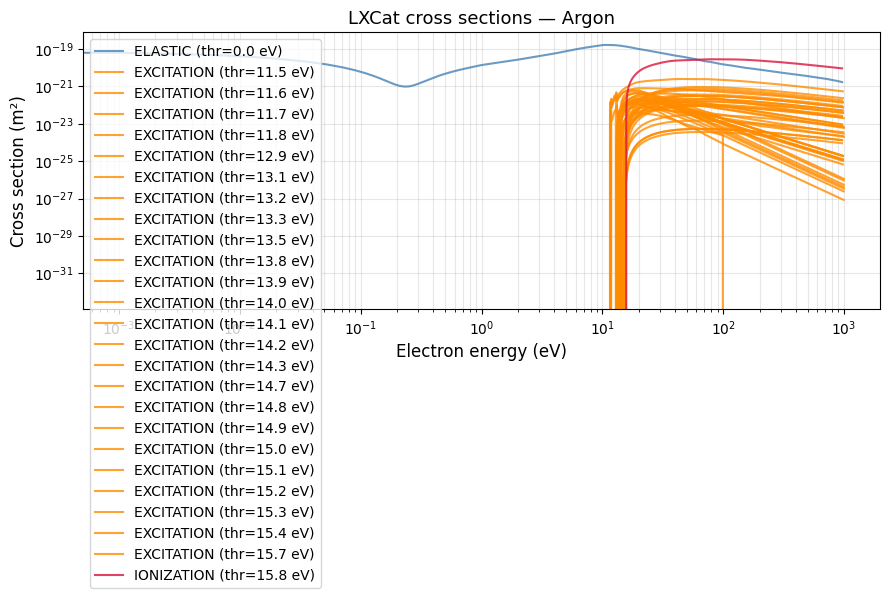

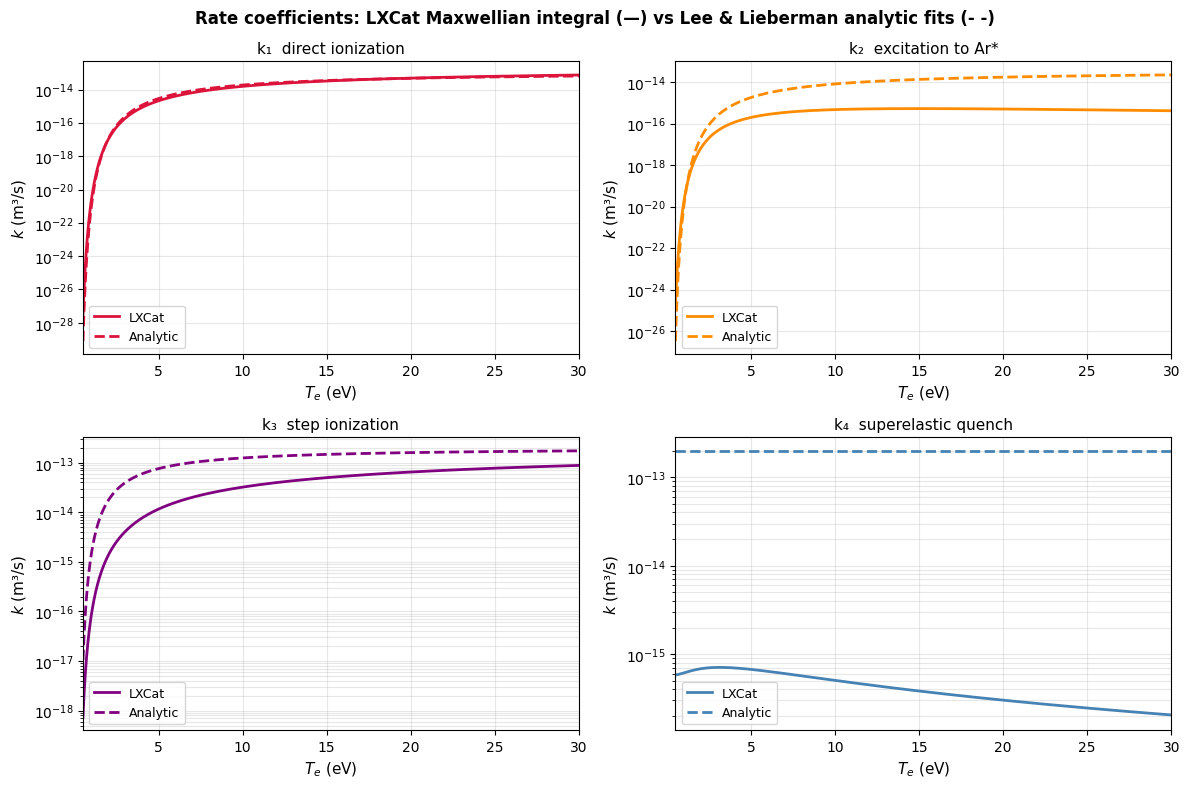

Saved: rate_comparison.png
[4] Running self-consistent pressure sweep (P = 1000 W)…
   p [mTorr]     Te [eV]      ne [cm^-3]      n* [cm^-3]    eps_L [eV]
----------------------------------------------------------------------
        0.10      14.344       5.061e+10       7.346e+09         15.88
        0.29       7.194       1.290e+11       3.689e+10         16.07
        0.86       4.731       2.335e+11       1.105e+11         16.34
        2.54       3.400       4.199e+11       2.802e+11         16.61
        7.47       2.557       8.213e+11       5.758e+11         16.82
       21.97       2.013       1.606e+12       8.964e+11         17.21
       64.58       1.651       2.890e+12       1.135e+12         18.39
      189.88       1.397       4.512e+12       1.248e+12         22.26


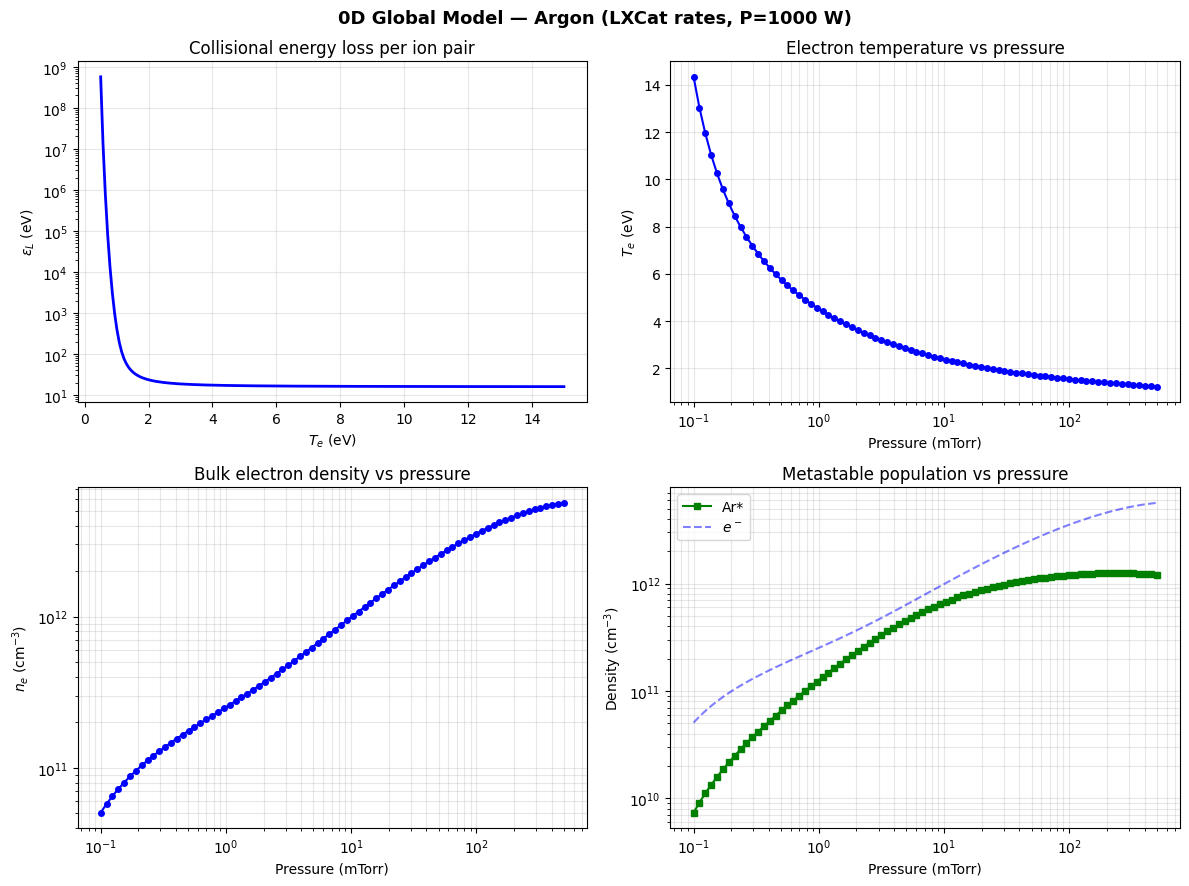


[5] Power sweep at 5 mTorr…


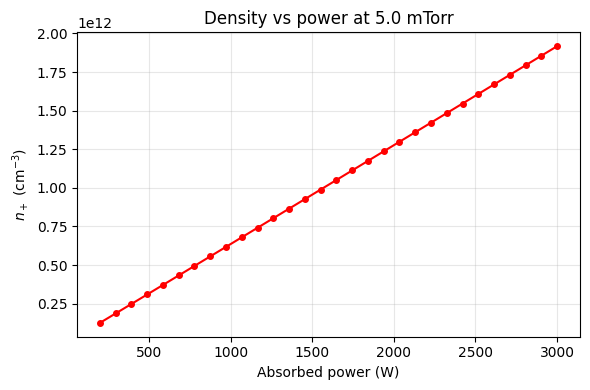


Single-point diagnostic at p=5.0 mTorr, P=1000 W:
  Te     = 2.828 eV
  ne     = 6.358e+11 cm^-3
  n*     = 4.550e+11 cm^-3
  k1     = 1.289e-16 m^3/s  (direct ionization)
  k2     = 3.560e-17 m^3/s  (excitation to Ar*)
  k3     = 3.513e-15 m^3/s  (step ionization)
  k4     = 7.066e-16 m^3/s  (superelastic)
  k5     = 6.200e-16 m^3/s  (pooling, fixed)

Done.


In [6]:
"""
=============================================================================
  0D Global Model for Argon High-Density Plasma Discharge
  Based on: Lee & Lieberman, J. Vac. Sci. Technol. A 13, 368 (1995)

  Rate coefficients computed from LXCat cross sections integrated
  over a Maxwellian EEDF, replacing the original analytic fits.

COLAB USAGE:
  1. !pip install numpy scipy matplotlib
  2. Upload your LXCat .txt file
  3. Set LXCAT_FILE to your filename
  4. Run: %run argon_global_lxcat.py
=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.constants import e, k, m_e, m_u, pi
import os, re, warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONSTANTS & REACTOR GEOMETRY
# ============================================================
e_charge = e
kB       = k
M_Ar     = 39.948 * m_u

L = 0.30
R = 0.15
V = pi * R**2 * L
A_total = 2*pi*R*L + 2*pi*R**2

print("=" * 60)
print("  0D Global Model — Argon Discharge (LXCat rates)")
print("  Lee & Lieberman, JVST A 13, 368 (1995)")
print("=" * 60)
print(f"Reactor: L={L*100:.2f} cm, R={R*100:.2f} cm")
print(f"Volume = {V*1e6:.1f} cm^3,  Wall area = {A_total*1e4:.1f} cm^2\n")


# ============================================================
# LXCAT PARSER
# ============================================================

# ---------- SET YOUR FILENAME HERE ----------
LXCAT_FILE = "Cross section allar.txt"
# --------------------------------------------

def parse_lxcat(filepath):
    """
    Parse a standard LXCat cross section file.

    Recognised block types: ELASTIC, EFFECTIVE, EXCITATION, IONIZATION.
    Each block becomes a dict with keys:
      type, process, threshold, mass_ratio, energy [eV], sigma [m^2]

    LXCat block structure:
      BLOCK_TYPE
      process string
      threshold_or_mass_ratio        (one float on its own line)
      ----...----                    (dashes mark start of data)
      energy   sigma
      ...
      ----...----                    (dashes mark end of data)
    """
    if not os.path.isfile(filepath):
        raise FileNotFoundError(
            f"\nFile not found: '{filepath}'\n"
            "Upload your LXCat .txt file and set LXCAT_FILE at the top of this script."
        )

    with open(filepath, 'r', errors='replace') as fh:
        text = fh.read()

    # Locate every block header
    header_re = re.compile(
        r'^(ELASTIC|EFFECTIVE|EXCITATION|IONIZATION)\s*$', re.MULTILINE
    )
    positions = [(m.group(1), m.start()) for m in header_re.finditer(text)]
    positions.append(('END', len(text)))

    processes = []
    for idx in range(len(positions) - 1):
        block_type, start = positions[idx]
        _, end            = positions[idx + 1]
        lines = text[start:end].splitlines()

        process_str = ''
        threshold   = 0.0
        mass_ratio  = 0.0
        data_rows   = []
        in_data     = False

        for line in lines[1:]:          # skip the block-type keyword line
            s = line.strip()
            if re.match(r'^-{5,}', s):  # dashed separator
                if in_data:
                    break               # second dashes = end of data table
                in_data = True
                continue

            if in_data:
                parts = s.split()
                if len(parts) == 2:
                    try:
                        data_rows.append((float(parts[0]), float(parts[1])))
                    except ValueError:
                        pass
            else:
                if s and not s.startswith('#'):
                    if not process_str:
                        process_str = s
                    else:
                        # numeric header lines carry threshold or mass ratio
                        parts = s.split()
                        try:
                            if block_type in ('ELASTIC', 'EFFECTIVE'):
                                mass_ratio = float(parts[0])
                            else:
                                threshold = float(parts[0])
                        except (ValueError, IndexError):
                            pass

        if not data_rows:
            continue

        energy = np.array([r[0] for r in data_rows])
        sigma  = np.array([r[1] for r in data_rows])

        # Zero cross section below threshold
        sigma[energy < threshold] = 0.0

        processes.append(dict(
            type       = block_type,
            process    = process_str,
            threshold  = threshold,
            mass_ratio = mass_ratio,
            energy     = energy,
            sigma      = sigma,
        ))

    if not processes:
        raise ValueError("No cross section blocks found — check your LXCat file format.")

    print(f"Parsed {len(processes)} cross section block(s) from '{filepath}':")
    for i, p in enumerate(processes):
        print(f"  [{i:2d}] {p['type']:12s}  thr={p['threshold']:6.2f} eV"
              f"  pts={len(p['energy'])}   {p['process'][:55]}")
    return processes


# ============================================================
# MAXWELLIAN EEDF RATE INTEGRATOR
# ============================================================

# Energy grid for integration [eV] — four-segment log-like spacing
_EPS = np.unique(np.concatenate([
    np.linspace(0,   1,    600),
    np.linspace(1,   20,  2000),
    np.linspace(20,  100, 1000),
    np.linspace(100, 1000, 400),
]))

# Te grid for pre-tabulation [eV]
_TE = np.logspace(-1, 2, 300)

# Prefactor sqrt(2e/m_e) converts eV energy axis to m/s velocity
_VEL_PREFACTOR = np.sqrt(2.0 * e_charge / m_e)   # m/s / sqrt(eV)


def _maxwellian(eps, Te):
    """Isotropic Maxwellian EEDF: f(eps,Te) = (2/sqrt(pi)) Te^{-3/2} sqrt(eps) exp(-eps/Te)."""
    return (2.0 / np.sqrt(np.pi)) * Te**(-1.5) * np.sqrt(np.maximum(eps, 0.0)) \
           * np.exp(-np.maximum(eps, 0.0) / Te)


def _k_from_sigma(sigma_fn, Te):
    """
    k(Te) = sqrt(2e/m_e) * integral_0^inf  sigma(eps) * sqrt(eps) * f_M(eps,Te)  d(eps)

    Uses trapezoidal integration on the pre-built _EPS grid.
    Returns k in m^3/s.
    """
    sv  = sigma_fn(_EPS)
    fMv = _maxwellian(_EPS, Te)
    return max(_VEL_PREFACTOR * np.trapz(sv * np.sqrt(np.maximum(_EPS, 0.0)) * fMv, _EPS), 0.0)


def _make_interp(energy, sigma):
    """Linear interpolant for sigma(eps); flat extrapolation beyond data range."""
    order = np.argsort(energy)
    return interp1d(energy[order], sigma[order],
                    kind='linear', bounds_error=False,
                    fill_value=(0.0, sigma[order][-1]))


def _build_k_interp(sigma_fn):
    """Pre-tabulate k over _TE and return a fast 1-D interpolant k(Te)."""
    kt = np.array([_k_from_sigma(sigma_fn, T) for T in _TE])
    return interp1d(_TE, kt, kind='linear', bounds_error=False,
                    fill_value=(kt[0], kt[-1]))


# ============================================================
# ROLE ASSIGNMENT — map LXCat blocks to k1..k5
# ============================================================

E_META  = 11.56    # Ar metastable excitation energy [eV]  (1s5 level)
G_RATIO = 1.0/3.0  # g_ground / g_meta for detailed balance

# Module-level interpolants (populated by _load_rates)
_k1_fn = None   # direct ionization
_k2_fn = None   # excitation to Ar*
_k3_fn = None   # step ionization from Ar*
_k4_fn = None   # superelastic quenching (detailed balance)
_k5    = 6.2e-16  # metastable pooling [m^3/s] — heavy-particle, fixed
_k_el_fn = None # elastic (for optional energy-loss extension)


def _load_rates(filepath):
    """Parse LXCat file, compute rate tables, populate module-level interpolants."""
    global _k1_fn, _k2_fn, _k3_fn, _k4_fn, _k_el_fn

    procs = parse_lxcat(filepath)

    # Separate by type
    ionization  = [p for p in procs if p['type'] == 'IONIZATION']
    excitation  = [p for p in procs if p['type'] == 'EXCITATION']
    elastic     = [p for p in procs if p['type'] in ('ELASTIC', 'EFFECTIVE')]

    print("\nBuilding Maxwellian rate coefficient tables…")

    # --- k1: direct ionization (threshold closest to 15.76 eV) ---
    if ionization:
        p1  = min(ionization, key=lambda p: abs(p['threshold'] - 15.76))
        fn1 = _make_interp(p1['energy'], p1['sigma'])
        _k1_fn = _build_k_interp(fn1)
        print(f"  k1  direct ionization  : '{p1['process'][:55]}'  thr={p1['threshold']:.2f} eV")
    else:
        print("  WARNING: no IONIZATION block — k1 uses analytic fallback")

    # --- k2: excitation to Ar* (threshold closest to 11.56 eV) ---
    if excitation:
        p2  = min(excitation, key=lambda p: abs(p['threshold'] - E_META))
        fn2 = _make_interp(p2['energy'], p2['sigma'])
        _k2_fn = _build_k_interp(fn2)
        print(f"  k2  excitation to Ar*  : '{p2['process'][:55]}'  thr={p2['threshold']:.2f} eV")
    else:
        print("  WARNING: no suitable EXCITATION block — k2 uses analytic fallback")

    # --- k3: step ionization e + Ar* → Ar+ + 2e ---
    # Same cross section as k1 but the energy axis is shifted down by E_META
    # (Ar* already carries E_META eV of internal energy).
    if ionization:
        raw_e = p1['energy']
        raw_s = p1['sigma'].copy()
        shifted_e = raw_e - E_META
        mask = shifted_e > 0
        if mask.sum() > 1:
            fn3 = _make_interp(shifted_e[mask], raw_s[mask])
        else:
            fn3 = lambda x: np.zeros_like(np.atleast_1d(x), dtype=float)
        _k3_fn = _build_k_interp(fn3)
        print(f"  k3  step ionisation    : shifted threshold = {max(p1['threshold']-E_META, 0):.2f} eV")
    else:
        print("  WARNING: no IONIZATION block — k3 uses analytic fallback")

    # --- k4: superelastic quenching via detailed balance ---
    # k4(Te) = k2(Te) * G_RATIO * exp(E_META / Te)  [capped at 1e-12 m^3/s]
    if _k2_fn is not None:
        k4_table = np.array([float(_k2_fn(T)) for T in _TE]) \
                   * G_RATIO * np.exp(E_META / _TE)
        k4_table = np.minimum(k4_table, 1e-12)
        _k4_fn   = interp1d(_TE, k4_table, kind='linear',
                             bounds_error=False,
                             fill_value=(k4_table[0], k4_table[-1]))
        print(f"  k4  superelastic       : detailed balance  G={G_RATIO:.3f}, E_meta={E_META} eV")
    else:
        print("  WARNING: k2 unavailable — k4 uses constant fallback")

    # --- elastic ---
    if elastic:
        pe  = elastic[0]
        fne = _make_interp(pe['energy'], pe['sigma'])
        _k_el_fn = _build_k_interp(fne)
        print(f"  k_el elastic           : '{pe['process'][:55]}'")

    print("Rate tables ready.\n")


# ============================================================
# rate_coefficients — REPLACES the original analytic version
# ============================================================

def rate_coefficients(Te):
    """
    Return (k1, k2, k3, k4, k5) in m^3/s.

    If LXCat data are loaded (normal operation): values come from
    integrating LXCat cross sections over the Maxwellian EEDF.

    Analytic fallbacks (Lee & Lieberman Table III) are used only when
    the corresponding LXCat block was absent in the file.
    """
    # --- k1 direct ionization ---
    if _k1_fn is not None:
        k1 = float(_k1_fn(Te))
    else:
        k1 = 1.23e-7 * np.exp(-18.68 / Te) * 1e-6

    # --- k2 excitation to Ar* ---
    if _k2_fn is not None:
        k2 = float(_k2_fn(Te))
    else:
        k2 = 3.71e-8 * np.exp(-15.06 / Te) * 1e-6

    # --- k3 step ionization ---
    if _k3_fn is not None:
        k3 = float(_k3_fn(Te))
    else:
        k3 = 2.05e-7 * np.exp(-4.95 / Te) * 1e-6

    # --- k4 superelastic quenching ---
    if _k4_fn is not None:
        k4 = float(_k4_fn(Te))
    else:
        k4 = 2.0e-7 * 1e-6

    # --- k5 metastable pooling (always fixed) ---
    k5 = _k5

    return k1, k2, k3, k4, k5


# ============================================================
# PHYSICS UTILITIES  (unchanged from your version)
# ============================================================

def bohm_velocity(Te):
    return np.sqrt(e_charge * Te / M_Ar)

def neutral_density(pressure_mTorr):
    T_neutral = 600.0
    pressure_Pa = pressure_mTorr * 0.1333
    return pressure_Pa / (kB * T_neutral)

def mean_free_path(pressure_mTorr):
    n_gas = neutral_density(pressure_mTorr)
    sigma = 3.67e-19
    return 1.0 / (np.sqrt(2) * sigma * n_gas)

def geometry_factors(Te, pressure_mTorr, Ti_eV=0.05):
    lam  = mean_free_path(pressure_mTorr)
    uB   = bohm_velocity(Te)
    g    = Te / Ti_eV

    nu_in = uB / lam if lam > 0 else 1e10
    Da    = (e_charge * Te) / (M_Ar * nu_in)

    term_axial = (0.86 * L * uB / (pi * Da))**2
    hL = 0.86 / np.sqrt(3 + L / (2 * lam) + term_axial)

    J1_2405   = 0.5191
    term_rad  = (0.8 * R * uB / (2.405 * J1_2405 * g * Da))**2
    hR = 0.8  / np.sqrt(4 + R / lam + term_rad)

    return hL, hR

def effective_area(Te, pressure_mTorr):
    hL, hR = geometry_factors(Te, pressure_mTorr)
    Aeff = hL * 2 * pi * R**2 + hR * 2 * pi * R * L
    return Aeff, hL, hR


# ============================================================
# COMPONENT RESOLUTION  (unchanged from your version)
# ============================================================

def metastable_density(Te, ne, pressure_mTorr):
    k1, k2, k3, k4, k5 = rate_coefficients(Te)
    n_Ar = neutral_density(pressure_mTorr)

    Lambda2_inv = (pi/L)**2 + (2.405/R)**2
    T_neutral   = 600.0
    v_th  = np.sqrt(8 * kB * T_neutral / (pi * M_Ar))
    DKN   = v_th / (3 * np.sqrt(Lambda2_inv))
    sigma_Ar = 3.67e-19
    DAA   = (3/16) * (1/(n_Ar * sigma_Ar)) * np.sqrt(pi * kB * T_neutral / M_Ar)
    Deff  = 1.0 / (1.0/DAA + 1.0/DKN) if (DAA > 0 and DKN > 0) else min(DAA, DKN)

    loss_rate   = ne * (k3 + k4) + Deff * Lambda2_inv
    discriminant = loss_rate**2 + 4 * k5 * ne * k2 * n_Ar
    return max((-loss_rate + np.sqrt(discriminant)) / (2 * k5), 0.0)

def energy_loss_per_pair(Te, n_star, ne, pressure_mTorr):
    k1, k2, k3, k4, k5 = rate_coefficients(Te)
    n_Ar = neutral_density(pressure_mTorr)

    epsilon_iz  = 15.76
    epsilon_iz3 = 4.20
    epsilon_exc = 11.56
    k_el        = float(_k_el_fn(Te)) if _k_el_fn is not None else 2.0e-13
    epsilon_el  = 3.0 * (m_e / M_Ar) * Te

    nu_iz1      = k1 * n_Ar
    nu_iz3      = k3 * n_star
    nu_iz_total = nu_iz1 + nu_iz3
    nu_exc      = k2 * n_Ar
    nu_el       = k_el * n_Ar
    nu_q        = k4 * n_star

    if nu_iz_total <= 0:
        return 100.0

    e_gain = (nu_q / nu_iz_total) * epsilon_exc
    eps_L  = (
          (nu_iz1 / nu_iz_total) * epsilon_iz
        + (nu_iz3 / nu_iz_total) * epsilon_iz3
        + (nu_exc / nu_iz_total) * epsilon_exc
        + (nu_el  / nu_iz_total) * epsilon_el
        - e_gain
    )
    return max(eps_L, 1.0)


# ============================================================
# CORE BALANCES & SOLVER  (unchanged from your version)
# ============================================================

def solve_density(Te, pressure_mTorr, P_abs_W):
    uB          = bohm_velocity(Te)
    _, hL, hR   = effective_area(Te, pressure_mTorr)
    n_star      = metastable_density(Te, 1e16, pressure_mTorr)
    eps_L       = energy_loss_per_pair(Te, n_star, 1e16, pressure_mTorr)
    epsilon_T   = eps_L + 5.0 * Te + 2.0 * Te
    loss_factor = (hL * 2*pi*R**2 + hR * 2*pi*R*L) * uB * epsilon_T * e_charge
    return P_abs_W / loss_factor

def solve_system_self_consistent(pressure_mTorr, P_abs_W, max_iter=30, tol=1e-4):
    ne_guess = 1e16
    Te_guess = 3.0
    for _ in range(max_iter):
        ne_old = ne_guess
        def particle_residual(T):
            k1, _, k3, _, _ = rate_coefficients(T)
            n_Ar   = neutral_density(pressure_mTorr)
            uB     = bohm_velocity(T)
            Aeff,_,_ = effective_area(T, pressure_mTorr)
            n_star = metastable_density(T, ne_guess, pressure_mTorr)
            return V * (k1 * n_Ar + k3 * n_star) - Aeff * uB
        try:
            Te_guess = brentq(particle_residual, 0.4, 25.0, xtol=1e-5)
        except ValueError:
            pass
        ne_guess = solve_density(Te_guess, pressure_mTorr, P_abs_W)
        if abs(ne_guess - ne_old) / ne_old < tol:
            break
    return Te_guess, ne_guess


# ============================================================
# DIAGNOSTIC: rate coefficient comparison plot
# ============================================================

def plot_rate_comparison():
    """LXCat-derived k(Te) (solid) vs original analytic fits (dashed)."""
    Te_arr = np.logspace(-0.3, 1.5, 200)

    k1_lx = np.array([float(_k1_fn(T)) if _k1_fn else 0 for T in Te_arr])
    k2_lx = np.array([float(_k2_fn(T)) if _k2_fn else 0 for T in Te_arr])
    k3_lx = np.array([float(_k3_fn(T)) if _k3_fn else 0 for T in Te_arr])
    k4_lx = np.array([float(_k4_fn(T)) if _k4_fn else 0 for T in Te_arr])

    k1_an = 1.23e-7 * np.exp(-18.68 / Te_arr) * 1e-6
    k2_an = 3.71e-8 * np.exp(-15.06 / Te_arr) * 1e-6
    k3_an = 2.05e-7 * np.exp(-4.95  / Te_arr) * 1e-6
    k4_an = np.full_like(Te_arr, 2.0e-7 * 1e-6)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Rate coefficients: LXCat Maxwellian integral (—) vs '
                 'Lee & Lieberman analytic fits (- -)',
                 fontsize=12, fontweight='bold')

    spec = [
        (axes[0,0], k1_lx, k1_an, 'k₁  direct ionization',    'crimson'),
        (axes[0,1], k2_lx, k2_an, 'k₂  excitation to Ar*',    'darkorange'),
        (axes[1,0], k3_lx, k3_an, 'k₃  step ionization',      'purple'),
        (axes[1,1], k4_lx, k4_an, 'k₄  superelastic quench',  'steelblue'),
    ]
    for ax, klx, kan, title, col in spec:
        m = klx > 0
        if m.sum() > 1:
            ax.semilogy(Te_arr[m], klx[m], color=col, lw=2, label='LXCat')
        ma = kan > 1e-30
        ax.semilogy(Te_arr[ma], kan[ma], color=col, lw=2, ls='--', label='Analytic')
        ax.set_xlabel('$T_e$ (eV)', fontsize=11)
        ax.set_ylabel('$k$ (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, which='both')
        ax.set_xlim([0.5, 30])

    plt.tight_layout()
    plt.savefig('rate_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: rate_comparison.png")

def plot_cross_sections(processes):
    """Plot all parsed cross sections."""
    colours = {'ELASTIC':'steelblue','EFFECTIVE':'steelblue',
               'EXCITATION':'darkorange','IONIZATION':'crimson'}
    plt.figure(figsize=(9, 5))
    seen = set()
    for p in processes:
        col   = colours.get(p['type'], 'gray')
        label = f"{p['type']} (thr={p['threshold']:.1f} eV)"
        kw    = {} if label in seen else {'label': label}
        seen.add(label)
        plt.loglog(p['energy'], p['sigma'], color=col, lw=1.5, alpha=0.8, **kw)
    plt.xlabel('Electron energy (eV)', fontsize=12)
    plt.ylabel('Cross section (m²)',   fontsize=12)
    plt.title('LXCat cross sections — Argon', fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.savefig('lxcat_cross_sections.png', dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================
# EXPERIMENT PIPELINES  (unchanged from your version)
# ============================================================

def run_pressure_sweep(P_abs_W=1000.0):
    pressures_mTorr = np.logspace(-1, 2.7, 80)
    results = {k: np.zeros(len(pressures_mTorr))
               for k in ('p','Te','ne','n_star','eps_L','hL','hR')}
    results['p'] = pressures_mTorr

    print(f"{'p [mTorr]':>12}  {'Te [eV]':>10}  {'ne [cm^-3]':>14}"
          f"  {'n* [cm^-3]':>14}  {'eps_L [eV]':>12}")
    print("-" * 70)

    for i, p in enumerate(pressures_mTorr):
        Te, ne = solve_system_self_consistent(p, P_abs_W)
        if np.isnan(Te) or ne <= 0:
            continue
        n_star = metastable_density(Te, ne, p)
        eps_L  = energy_loss_per_pair(Te, n_star, ne, p)
        _, hL, hR = effective_area(Te, p)
        results['Te'][i]     = Te
        results['ne'][i]     = ne
        results['n_star'][i] = n_star
        results['eps_L'][i]  = eps_L
        results['hL'][i]     = hL
        results['hR'][i]     = hR
        if i % 10 == 0:
            print(f"  {p:10.2f}  {Te:10.3f}  {ne*1e-6:14.3e}"
                  f"  {n_star*1e-6:14.3e}  {eps_L:12.2f}")
    return results

def plot_results(results, P_abs_W=1000.0):
    p, Te, ne, n_star, eps_L = (results[k] for k in ('p','Te','ne','n_star','eps_L'))
    valid = (Te > 0) & (ne > 0)
    p, Te, ne, n_star, eps_L = [a[valid] for a in (p, Te, ne, n_star, eps_L)]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f'0D Global Model — Argon (LXCat rates, P={P_abs_W:.0f} W)',
                 fontsize=13, fontweight='bold')

    ax = axes[0,0]
    Te_r = np.linspace(0.5, 15, 200)
    ax.semilogy(Te_r, [energy_loss_per_pair(T, metastable_density(T,1e16,5.), 1e16, 5.)
                        for T in Te_r], 'b-', lw=2)
    ax.set_xlabel('$T_e$ (eV)'); ax.set_ylabel('$\\epsilon_L$ (eV)')
    ax.set_title('Collisional energy loss per ion pair'); ax.grid(True, alpha=0.3)

    ax = axes[0,1]
    ax.semilogx(p, Te, 'b-o', ms=4, lw=1.5)
    ax.set_xlabel('Pressure (mTorr)'); ax.set_ylabel('$T_e$ (eV)')
    ax.set_title('Electron temperature vs pressure')
    ax.grid(True, alpha=0.3, which='both')

    ax = axes[1,0]
    ax.loglog(p, ne*1e-6, 'b-o', ms=4, lw=1.5)
    ax.set_xlabel('Pressure (mTorr)'); ax.set_ylabel('$n_e$ (cm$^{-3}$)')
    ax.set_title('Bulk electron density vs pressure')
    ax.grid(True, alpha=0.3, which='both')

    ax = axes[1,1]
    ax.loglog(p, n_star*1e-6, 'g-s', ms=4, label='Ar*')
    ax.loglog(p, ne*1e-6,     'b--', alpha=0.5, label='$e^-$')
    ax.set_xlabel('Pressure (mTorr)'); ax.set_ylabel('Density (cm$^{-3}$)')
    ax.set_title('Metastable population vs pressure')
    ax.legend(); ax.grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    plt.savefig('argon_global_model_lxcat.png', dpi=150)
    plt.show()

def run_power_sweep(pressure_mTorr=5.0):
    powers_W  = np.linspace(200, 3000, 30)
    densities = [solve_system_self_consistent(pressure_mTorr, P)[1] for P in powers_W]
    plt.figure(figsize=(6,4))
    plt.plot(powers_W, np.array(densities)*1e-6, 'r-o', ms=4)
    plt.xlabel('Absorbed power (W)'); plt.ylabel('$n_+$ (cm$^{-3}$)')
    plt.title(f'Density vs power at {pressure_mTorr} mTorr')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig('argon_power_sweep_lxcat.png', dpi=150)
    plt.show()


# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":

    # 1. Load LXCat cross sections and build rate tables
    _load_rates(LXCAT_FILE)

    # 2. Plot the raw cross sections
    plot_cross_sections(parse_lxcat(LXCAT_FILE))

    # 3. Compare LXCat-derived rates against analytic fits
    plot_rate_comparison()

    # 4. Pressure sweep
    print("[4] Running self-consistent pressure sweep (P = 1000 W)…")
    data = run_pressure_sweep(P_abs_W=1000.0)
    plot_results(data, P_abs_W=1000.0)

    # 5. Power sweep at 5 mTorr
    print("\n[5] Power sweep at 5 mTorr…")
    run_power_sweep(pressure_mTorr=5.0)

    # 6. Single-point diagnostic
    p0 = 5.0
    Te0, ne0 = solve_system_self_consistent(p0, 1000.0)
    ns0 = metastable_density(Te0, ne0, p0)
    k1, k2, k3, k4, k5 = rate_coefficients(Te0)
    print(f"\nSingle-point diagnostic at p={p0} mTorr, P=1000 W:")
    print(f"  Te     = {Te0:.3f} eV")
    print(f"  ne     = {ne0*1e-6:.3e} cm^-3")
    print(f"  n*     = {ns0*1e-6:.3e} cm^-3")
    print(f"  k1     = {k1:.3e} m^3/s  (direct ionization)")
    print(f"  k2     = {k2:.3e} m^3/s  (excitation to Ar*)")
    print(f"  k3     = {k3:.3e} m^3/s  (step ionization)")
    print(f"  k4     = {k4:.3e} m^3/s  (superelastic)")
    print(f"  k5     = {k5:.3e} m^3/s  (pooling, fixed)")
    print("\nDone.")

In [12]:
"""
=============================================================================
  Reproduction of Figures 2–6 from:
  J T Gudmundsson, Plasma Sources Sci. Technol. 10 (2001) 76–81

  "On the effect of the electron energy distribution on the plasma
   parameters of an argon discharge: a global (volume-averaged) model study"

  Generalized EEDF:  f(E) = c1 * E^{1/2} * exp(-c2 * E^x)
    x = 1  → Maxwellian
    x = 2  → Druyvesteyn

  Reactor geometry (paper §2.5):  R = 15.24 cm, L = 7.62 cm
  Neutral gas temperature: Tg = 473 K
  Absorbed power (figs 5,6): Pabs = 500 W
=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.special import gamma
from scipy.optimize import brentq
from scipy.constants import e, k as kB, m_e, m_u, pi

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS & GEOMETRY  (paper values)
# ─────────────────────────────────────────────────────────────────────────────
M_Ar   = 39.948 * m_u
R      = 0.1524          # m  (15.24 cm)
L      = 0.0762          # m  ( 7.62 cm)
V      = pi * R**2 * L
Tg     = 473.0           # K  neutral gas temperature
e_ch   = e

# Ion–neutral momentum transfer cross section (§2.4)
sigma_in = 1.0e-18       # m²

# ─────────────────────────────────────────────────────────────────────────────
# GENERALISED EEDF  — equations (1)–(9) of the paper
# ─────────────────────────────────────────────────────────────────────────────

def eedf_params(Teff, x):
    """
    Return (c1, c2) for  f(E) = c1 E^{1/2} exp(-c2 E^x).
    Teff is in eV; c1 in eV^{-3/2}, c2 in eV^{-x}.
    """
    xi1 = 3.0 / (2.0 * x)
    xi2 = 5.0 / (2.0 * x)
    E_mean = 1.5 * Teff          # mean energy in eV
    c2 = (1.0 / E_mean) * (gamma(xi2) / gamma(xi1))**x
    c1 = x * (gamma(xi2)**1.5) / (E_mean**1.5 * gamma(xi1)**2.5)
    return c1, c2


def f_eedf(E, Teff, x):
    """Generalised EEDF f(E) [eV^{-3/2}] at energy E [eV]."""
    c1, c2 = eedf_params(Teff, x)
    E = np.maximum(E, 0.0)
    return c1 * np.sqrt(E) * np.exp(-c2 * E**x)


# Pre-built energy grid for integrals
_EG = np.concatenate([
    np.linspace(0,    1,    800),
    np.linspace(1,    20,  3000),
    np.linspace(20,   100, 1000),
    np.linspace(100,  500,  400),
])


def rate_coeff_from_cs(energy_eV, sigma_m2, Teff, x):
    """
    k = sqrt(2e/m_e) * integral  sigma(E) * E * f(E) dE   [m³/s]

    The factor sqrt(E) from f(E) × sqrt(E) gives E, which is the
    speed-weighted integrand.  Full expression:
        k = sqrt(2e/m_e) * ∫ sigma(E) * sqrt(E) * f(E) dE   m^3/s
    """
    # Interpolate sigma onto the integration grid
    from scipy.interpolate import interp1d
    if len(energy_eV) < 2:
        return 0.0
    sig_fn = interp1d(energy_eV, sigma_m2, kind='linear',
                      bounds_error=False, fill_value=(0.0, sigma_m2[-1]))
    sig_g  = sig_fn(_EG)
    sig_g[_EG < energy_eV[0]] = 0.0
    fv     = f_eedf(_EG, Teff, x)
    prefac = np.sqrt(2.0 * e_ch / m_e)
    integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return max(prefac * integrate(sig_g * np.sqrt(np.maximum(_EG, 0.0)) * fv, _EG), 0.0)


# ─────────────────────────────────────────────────────────────────────────────
# CROSS SECTIONS  (digitised / analytic fits from cited references)
# ─────────────────────────────────────────────────────────────────────────────
# Ionisation: Straub et al, PRA 52, 1115 (1995)
# We use a standard analytic fit to Straub's data (good to ~5 %)
def _straub_ionization():
    """Ionization cross section [m²] vs energy [eV] — Straub et al 1995."""
    E = np.array([15.76, 16, 17, 18, 19, 20, 22, 25, 30, 35, 40, 50,
                  60, 70, 80, 100, 120, 150, 200, 300, 500, 1000])
    # Analytic Lotz-type fit calibrated to Straub's peak (~3.5×10⁻²⁰ m² at 50 eV)
    s = np.zeros_like(E, dtype=float)
    for i, en in enumerate(E):
        if en > 15.76:
            s[i] = 1.0e-20 * (en - 15.76) / en * (3.5 / (1 + ((en - 50)/80)**2) + 0.5)
    return E, s


# Excitation cross sections:  Tachibana 1986 (4s states) + Eggarter 1975 (higher)
# We use analytic fits to the published data for each group.

def _cs_excitation_group(Eth_eV, peak_m2, E_peak, width):
    """Simple bell-curve excitation cross section for a group of states."""
    E = np.linspace(0, 500, 5000)
    s = np.where(E > Eth_eV,
                 peak_m2 * ((E - Eth_eV) / (E_peak - Eth_eV))
                           * np.exp(-(E - E_peak)**2 / (2 * width**2)),
                 0.0)
    return E, np.maximum(s, 0.0)


# Excitation groups from paper (Table 1):
# 4s states: Tachibana (3P2=11.5, 3P1=11.6, 3P0=11.7, 1P1=11.8 eV)
# 4p states: Eggarter, threshold 13.2 eV
# Groups II  (5s,3d...) : 14.2 eV
# Groups III (4d,6s...) : 15.0 eV
# Group  IV  (6s',5d..): 15.5 eV

_EXCITATION_GROUPS = [
    # (threshold eV, peak cross section m², peak energy eV, width eV, label)
    (11.55, 1.5e-21,  14.0, 3.0,  '4s (Tachibana)'),
    (13.20, 2.5e-21,  18.0, 5.0,  '4p (Eggarter)'),
    (14.20, 1.0e-21,  20.0, 6.0,  'II (5s,3d)'),
    (15.00, 0.8e-21,  22.0, 7.0,  'III (4d,6s)'),
    (15.50, 0.5e-21,  23.0, 7.0,  'IV (6s\',5d)'),
]

# Elastic / momentum transfer  — fit to Milloy et al / Phelps data
def _cs_elastic():
    E = np.logspace(-2, 3, 2000)
    # Ramsauer minimum near 0.25 eV, rises at high energy
    s = 1e-19 * (0.9 / (1 + (E/0.25)**2) + 0.1 + 0.004 * E**0.6)
    return E, np.maximum(s, 0.0)


# ─────────────────────────────────────────────────────────────────────────────
# RATE COEFFICIENTS AS FUNCTION OF Teff AND x
# ─────────────────────────────────────────────────────────────────────────────

_E_iz, _S_iz = _straub_ionization()
_E_el, _S_el = _cs_elastic()


def Kiz(Teff, x):
    """Ionisation rate coefficient [m³/s]."""
    return rate_coeff_from_cs(_E_iz, _S_iz, Teff, x)


def Kex_groups(Teff, x):
    """List of (threshold_eV, rate_coeff_m3/s) for each excitation group."""
    result = []
    for (Eth, pk, Epk, wid, lbl) in _EXCITATION_GROUPS:
        Eg, Sg = _cs_excitation_group(Eth, pk, Epk, wid)
        result.append((Eth, rate_coeff_from_cs(Eg, Sg, Teff, x)))
    return result


def Kel(Teff, x):
    """Elastic (momentum transfer) rate coefficient [m³/s]."""
    return rate_coeff_from_cs(_E_el, _S_el, Teff, x)


# ─────────────────────────────────────────────────────────────────────────────
# COLLISIONAL ENERGY LOSS  Ec(Teff, x)  — equation (26)
# ─────────────────────────────────────────────────────────────────────────────

def Ec_func(Teff, x):
    """
    Collisional energy loss per electron–ion pair [eV].
    Ec = Eiz + sum_i( Eex,i * Kex,i/Kiz ) + Kel/Kiz * (3 me/mi) * Teff
    """
    kiz = Kiz(Teff, x)
    if kiz <= 0:
        return 1e6
    Eiz = 15.76
    exc_groups = Kex_groups(Teff, x)
    exc_term = sum(Eth * kex / kiz for (Eth, kex) in exc_groups)
    kel   = Kel(Teff, x)
    el_term = (kel / kiz) * 3.0 * (m_e / M_Ar) * Teff
    return Eiz + exc_term + el_term


# ─────────────────────────────────────────────────────────────────────────────
# ION VELOCITY  — equation (12)
# ─────────────────────────────────────────────────────────────────────────────

def ion_velocity(Teff, x):
    """
    General Bohm velocity [m/s]:
    vi = sqrt(2 Emean / mi) * Gamma(xi1) / sqrt(Gamma(xi2)*Gamma(xi3))
    with Emean = 1.5 Teff [eV].
    """
    xi1 = 3.0 / (2.0 * x)
    xi2 = 5.0 / (2.0 * x)
    xi3 = 1.0 / (2.0 * x)
    E_mean = 1.5 * Teff * e_ch  # J
    prefac = np.sqrt(2.0 * E_mean / M_Ar)
    vi = prefac * gamma(xi1) / np.sqrt(gamma(xi2) * gamma(xi3))
    return vi


# ─────────────────────────────────────────────────────────────────────────────
# SHEATH VOLTAGE  Vs(Teff, x)  — equation (15) solved numerically
# ─────────────────────────────────────────────────────────────────────────────

def sheath_voltage(Teff, x):
    """
    Find Vs [V] by equating electron flux to ion flux at the wall.
    Uses equation (15) for electron flux and equation (12) for ion velocity.
    """
    c1, c2 = eedf_params(Teff, x)
    vi     = ion_velocity(Teff, x)
    E_mean = 1.5 * Teff  # eV

    def residual(Vs):
        # Electron flux integral  (equation 15, divided by 1/4 ns ve_bar c1)
        # int_{Vs}^{inf} (E-Vs)^{1/2} exp(-c2 E^x) dE  = vi * [normalisation]
        # We set ns=1 and absorb the common factor:
        # e_flux = (1/4) ve_bar * c1 * integral
        # i_flux = vi   (relative to ns)
        E_int = np.linspace(Vs, max(Vs + 10 * Teff, 100), 3000)
        integrand = np.sqrt(np.maximum(E_int - Vs, 0.0)) * np.exp(-c2 * E_int**x)
        integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
        integral  = integrate(integrand, E_int)

        xi1 = 3.0 / (2.0 * x);  xi2 = 5.0 / (2.0 * x)
        xi4 = 2.0 / x
        ve_bar = np.sqrt(2.0 * e_ch * E_mean / m_e) * gamma(xi4) / \
                 np.sqrt(gamma(xi1) * gamma(xi2))

        e_flux = 0.25 * ve_bar * c1 * integral   # proportional to ns
        i_flux = vi                               # proportional to ns (sheath edge)

        # Normalise: equate dimensionless forms
        # Full condition:  0.25 * ve_bar * n_s * c1 * integral  =  n_s * vi
        return e_flux - i_flux

    try:
        Vs = brentq(residual, 0.1, 30.0 * Teff, xtol=1e-4)
    except ValueError:
        Vs = 4.68 * Teff if x == 1 else 3.43 * Teff  # fallback
    return Vs


# ─────────────────────────────────────────────────────────────────────────────
# ENERGY TERMS  Ee and Ei  — equations (16) and (17)
# ─────────────────────────────────────────────────────────────────────────────

def Ee_func(Teff, x):
    """Mean kinetic energy lost per electron lost [eV] — equation (16)."""
    xi1 = 3.0 / (2.0 * x);  xi2 = 5.0 / (2.0 * x)
    xi4 = 2.0 / x;          xi5 = 3.0 / x
    E_mean = 1.5 * Teff
    return gamma(xi1) * gamma(xi5) / (gamma(xi2) * gamma(xi4)) * E_mean


def Ei_func(Teff, x, Vs):
    """Mean kinetic energy lost per ion lost [eV] — equation (17)."""
    xi1 = 3.0 / (2.0 * x);  xi2 = 5.0 / (2.0 * x);  xi3 = 1.0 / (2.0 * x)
    E_mean = 1.5 * Teff
    return E_mean * (gamma(xi1))**2 / (gamma(xi2) * gamma(xi3)) + Vs


# ─────────────────────────────────────────────────────────────────────────────
# GEOMETRY FACTORS  hL, hR  — equations (18) and (19)
# ─────────────────────────────────────────────────────────────────────────────

def hL_hR(pressure_mTorr):
    """Density ratios at axial and radial sheath edges."""
    Tg_local  = Tg
    p_Pa = pressure_mTorr * 0.1333
    n_Ar = p_Pa / (kB * Tg_local)
    lam_i = 1.0 / (n_Ar * sigma_in)
    hL = 0.86 / np.sqrt(3.0 + L / (2.0 * lam_i))
    hR = 0.80 / np.sqrt(4.0 + R / lam_i)
    return hL, hR


def effective_area(pressure_mTorr):
    hL, hR = hL_hR(pressure_mTorr)
    return 2 * pi * R * (R * hL + L * hR), hL, hR


# ─────────────────────────────────────────────────────────────────────────────
# PARTICLE BALANCE → Teff  (equation 24)
# ─────────────────────────────────────────────────────────────────────────────

def solve_Teff(pressure_mTorr, x):
    """
    Solve  Kiz(Teff,x) / vi(Teff,x) = 1 / (ng * deff)
    for Teff [eV].
    """
    p_Pa = pressure_mTorr * 0.1333
    ng   = p_Pa / (kB * Tg)
    hL, hR = hL_hR(pressure_mTorr)
    deff = 0.5 * R * L / (R * hL + L * hR)

    def residual(T):
        kiz = Kiz(T, x)
        vi  = ion_velocity(T, x)
        if vi <= 0 or kiz <= 0:
            return -1.0
        return kiz / vi - 1.0 / (ng * deff)

    try:
        Teff = brentq(residual, 0.3, 30.0, xtol=1e-4, maxiter=200)
    except ValueError:
        Teff = float('nan')
    return Teff


# ─────────────────────────────────────────────────────────────────────────────
# POWER BALANCE → ne  (equation 22)
# ─────────────────────────────────────────────────────────────────────────────

def solve_ne(Teff, x, pressure_mTorr, Pabs_W):
    """
    ne = Pabs / (e * vi * Aeff * ET)
    """
    vi       = ion_velocity(Teff, x)
    Aeff, _, _ = effective_area(pressure_mTorr)
    Vs       = sheath_voltage(Teff, x)
    Ec       = Ec_func(Teff, x)
    Ee       = Ee_func(Teff, x)
    Ei       = Ei_func(Teff, x, Vs)
    ET       = Ec + Ee + Ei
    ne       = Pabs_W / (e_ch * vi * Aeff * ET)
    return ne, ET, Vs


# ─────────────────────────────────────────────────────────────────────────────
# PLOTTING HELPERS
# ─────────────────────────────────────────────────────────────────────────────

COLORS = {1.00: '#1f77b4', 1.25: '#ff7f0e', 1.50: '#2ca02c', 2.00: '#d62728'}
LABELS = {1.00: 'x = 1.00', 1.25: 'x = 1.25', 1.50: 'x = 1.50', 2.00: 'x = 2.00'}
X_VALS = [1.00, 1.25, 1.50, 2.00]

PCOLORS = {1: '#1f77b4', 2: '#ff7f0e', 5: '#2ca02c',
           10: '#d62728', 20: '#9467bd'}
PRESSURES = [1, 2, 5, 10, 20]   # mTorr

def paper_style(ax, xlabel, ylabel, title='', logx=False, logy=False,
                xlim=None, ylim=None):
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    if title:
        ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3, which='both')
    if logx: ax.set_xscale('log')
    if logy: ax.set_yscale('log')
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    ax.legend(fontsize=9)


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2:  Ec vs Teff for x = 1.00, 1.25, 1.50, 2.00
# ─────────────────────────────────────────────────────────────────────────────

def fig2():
    print("Computing Figure 2 — Ec vs Teff ...")
    Teff_arr = np.linspace(0.5, 12, 120)
    fig, ax = plt.subplots(figsize=(6, 5))
    for x in X_VALS:
        Ec_arr = np.array([Ec_func(T, x) for T in Teff_arr])
        ax.semilogy(Teff_arr, Ec_arr, color=COLORS[x], lw=2, label=LABELS[x])
    paper_style(ax,
        xlabel=r'$T_\mathrm{eff}$ (eV)',
        ylabel=r'$E_c$ (eV)',
        title='Fig 2 — Collisional energy loss per electron–ion pair',
        xlim=(0, 12), ylim=(1, 1e4))
    ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    plt.tight_layout()
    plt.savefig('/content/fig2_Ec_vs_Teff.png', dpi=150)
    plt.close()
    print("  → saved fig2_Ec_vs_Teff.png")


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3:  Teff vs x  at pressures 1, 2, 5, 10, 20 mTorr
# ─────────────────────────────────────────────────────────────────────────────

def fig3():
    print("Computing Figure 3 — Teff vs x ...")
    x_arr = np.linspace(1.0, 2.0, 25)
    fig, ax = plt.subplots(figsize=(6, 5))
    for p in PRESSURES:
        Teff_arr = np.array([solve_Teff(p, xv) for xv in x_arr])
        valid = ~np.isnan(Teff_arr)
        ax.plot(x_arr[valid], Teff_arr[valid],
                color=PCOLORS[p], lw=2, label=f'{p} mTorr')
    paper_style(ax,
        xlabel=r'$x$',
        ylabel=r'$T_\mathrm{eff}$ (eV)',
        title='Fig 3 — Effective electron temperature vs EEDF parameter $x$',
        xlim=(1, 2), ylim=(0, 8))
    plt.tight_layout()
    plt.savefig('/content/fig3_Teff_vs_x.png', dpi=150)
    plt.close()
    print("  → saved fig3_Teff_vs_x.png")


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4:  Vs vs x  at pressures 1, 2, 5, 10, 20 mTorr
# ─────────────────────────────────────────────────────────────────────────────

def fig4():
    print("Computing Figure 4 — Vs vs x ...")
    x_arr = np.linspace(1.0, 2.0, 25)
    fig, ax = plt.subplots(figsize=(6, 5))
    for p in PRESSURES:
        Vs_arr = []
        for xv in x_arr:
            Teff = solve_Teff(p, xv)
            if np.isnan(Teff):
                Vs_arr.append(float('nan'))
            else:
                Vs_arr.append(sheath_voltage(Teff, xv))
        Vs_arr = np.array(Vs_arr)
        valid = ~np.isnan(Vs_arr)
        ax.plot(x_arr[valid], Vs_arr[valid],
                color=PCOLORS[p], lw=2, label=f'{p} mTorr')
    paper_style(ax,
        xlabel=r'$x$',
        ylabel=r'$V_s$ (V)',
        title='Fig 4 — Sheath voltage vs EEDF parameter $x$',
        xlim=(1, 2), ylim=(0, 30))
    plt.tight_layout()
    plt.savefig('/content/fig4_Vs_vs_x.png', dpi=150)
    plt.close()
    print("  → saved fig4_Vs_vs_x.png")


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 5:  ne vs x  at pressures 1, 2, 5, 10, 20 mTorr, Pabs=500 W
# ─────────────────────────────────────────────────────────────────────────────

def fig5(Pabs=500.0):
    print(f"Computing Figure 5 — ne vs x (Pabs={Pabs} W) ...")
    x_arr = np.linspace(1.0, 2.0, 25)
    fig, ax = plt.subplots(figsize=(6, 5))
    for p in PRESSURES:
        ne_arr = []
        for xv in x_arr:
            Teff = solve_Teff(p, xv)
            if np.isnan(Teff):
                ne_arr.append(float('nan'))
            else:
                ne, _, _ = solve_ne(Teff, xv, p, Pabs)
                ne_arr.append(ne * 1e-16)   # in units of 10^16 m^-3
        ne_arr = np.array(ne_arr)
        valid = ~np.isnan(ne_arr) & (ne_arr > 0)
        ax.plot(x_arr[valid], ne_arr[valid],
                color=PCOLORS[p], lw=2, label=f'{p} mTorr')
    paper_style(ax,
        xlabel=r'$x$',
        ylabel=r'$n_e \times 10^{16}$ (m$^{-3}$)',
        title=f'Fig 5 — Electron density vs $x$  ($P_{{abs}}={Pabs:.0f}$ W)',
        xlim=(1, 2), ylim=(0, 45))
    plt.tight_layout()
    plt.savefig('/content/fig5_ne_vs_x.png', dpi=150)
    plt.close()
    print("  → saved fig5_ne_vs_x.png")


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 6:  ne vs pressure  for x = 1.00, 1.25, 1.50, 2.00, Pabs=500 W
# ─────────────────────────────────────────────────────────────────────────────

def fig6(Pabs=500.0):
    print(f"Computing Figure 6 — ne vs pressure (Pabs={Pabs} W) ...")
    p_arr = np.linspace(0.5, 50, 60)
    fig, ax = plt.subplots(figsize=(6, 5))
    for x in X_VALS:
        ne_arr = []
        for p in p_arr:
            Teff = solve_Teff(p, x)
            if np.isnan(Teff):
                ne_arr.append(float('nan'))
            else:
                ne, _, _ = solve_ne(Teff, x, p, Pabs)
                ne_arr.append(ne * 1e-16)
        ne_arr = np.array(ne_arr)
        valid = ~np.isnan(ne_arr) & (ne_arr > 0)
        ax.plot(p_arr[valid], ne_arr[valid],
                color=COLORS[x], lw=2, label=LABELS[x])
    paper_style(ax,
        xlabel=r'$p$ (mTorr)',
        ylabel=r'$n_e \times 10^{16}$ (m$^{-3}$)',
        title=f'Fig 6 — Electron density vs pressure  ($P_{{abs}}={Pabs:.0f}$ W)',
        xlim=(0, 50), ylim=(0, 70))
    plt.tight_layout()
    plt.savefig('/content/fig6_ne_vs_pressure.png', dpi=150)
    plt.close()
    print("  → saved fig6_ne_vs_pressure.png")


# ─────────────────────────────────────────────────────────────────────────────
# COMBINED FIGURE  (all 5 panels, paper layout)
# ─────────────────────────────────────────────────────────────────────────────

def fig_combined():
    print("\nGenerating combined figure (all panels) ...")
    x_vals_fine = np.linspace(1.0, 2.0, 30)
    p_arr_fine  = np.linspace(0.5, 50, 70)
    Teff_Te_arr = np.linspace(0.5, 12, 120)
    Pabs = 500.0

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(
        'Gudmundsson 2001 — Plasma Sources Sci. Technol. 10 (2001) 76\n'
        'Effect of EEDF on argon discharge plasma parameters',
        fontsize=13, fontweight='bold')

    # ── Panel (a): Fig 2 — Ec vs Teff ─────────────────────────────────────
    ax = axes[0, 0]
    for x in X_VALS:
        Ec_arr = np.array([Ec_func(T, x) for T in Teff_Te_arr])
        ax.semilogy(Teff_Te_arr, Ec_arr, color=COLORS[x], lw=2, label=LABELS[x])
    ax.set_xlabel(r'$T_\mathrm{eff}$ (eV)', fontsize=11)
    ax.set_ylabel(r'$E_c$ (eV)', fontsize=11)
    ax.set_title('(a) Fig 2: Collisional energy loss $E_c$', fontsize=10)
    ax.set_xlim(0, 12); ax.set_ylim(1, 1e4)
    ax.grid(True, alpha=0.3, which='both'); ax.legend(fontsize=8)

    # ── Panel (b): EEPF — Fig 1 (bonus) ────────────────────────────────────
    ax = axes[0, 1]
    E_plot = np.linspace(0.01, 16, 500)
    for x in X_VALS:
        eepf = f_eedf(E_plot, 3.0, x) / np.sqrt(np.maximum(E_plot, 1e-9))
        ax.semilogy(E_plot, eepf, color=COLORS[x], lw=2, label=LABELS[x])
    ax.set_xlabel('Electron energy (eV)', fontsize=11)
    ax.set_ylabel(r'EEPF (eV$^{-3/2}$ m$^{-3}$)', fontsize=11)
    ax.set_title('(b) Fig 1: EEPF at $T_\\mathrm{eff}=3$ eV', fontsize=10)
    ax.set_xlim(0, 16)
    ax.grid(True, alpha=0.3, which='both'); ax.legend(fontsize=8)

    # ── Panel (c): Fig 3 — Teff vs x ───────────────────────────────────────
    ax = axes[0, 2]
    for p in PRESSURES:
        Teff_arr = np.array([solve_Teff(p, xv) for xv in x_vals_fine])
        valid = ~np.isnan(Teff_arr)
        ax.plot(x_vals_fine[valid], Teff_arr[valid],
                color=PCOLORS[p], lw=2, label=f'{p} mTorr')
    ax.set_xlabel(r'$x$', fontsize=11)
    ax.set_ylabel(r'$T_\mathrm{eff}$ (eV)', fontsize=11)
    ax.set_title('(c) Fig 3: Effective electron temperature', fontsize=10)
    ax.set_xlim(1, 2); ax.set_ylim(0, 8)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

    # ── Panel (d): Fig 4 — Vs vs x ──────────────────────────────────────────
    ax = axes[1, 0]
    for p in PRESSURES:
        Vs_arr = []
        for xv in x_vals_fine:
            Teff = solve_Teff(p, xv)
            Vs_arr.append(sheath_voltage(Teff, xv) if not np.isnan(Teff) else float('nan'))
        Vs_arr = np.array(Vs_arr)
        valid  = ~np.isnan(Vs_arr)
        ax.plot(x_vals_fine[valid], Vs_arr[valid],
                color=PCOLORS[p], lw=2, label=f'{p} mTorr')
    ax.set_xlabel(r'$x$', fontsize=11)
    ax.set_ylabel(r'$V_s$ (V)', fontsize=11)
    ax.set_title('(d) Fig 4: Sheath voltage $V_s$', fontsize=10)
    ax.set_xlim(1, 2); ax.set_ylim(0, 30)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

    # ── Panel (e): Fig 5 — ne vs x ──────────────────────────────────────────
    ax = axes[1, 1]
    for p in PRESSURES:
        ne_arr = []
        for xv in x_vals_fine:
            Teff = solve_Teff(p, xv)
            if np.isnan(Teff):
                ne_arr.append(float('nan'))
            else:
                ne, _, _ = solve_ne(Teff, xv, p, Pabs)
                ne_arr.append(ne * 1e-16)
        ne_arr = np.array(ne_arr)
        valid  = ~np.isnan(ne_arr) & (ne_arr > 0)
        ax.plot(x_vals_fine[valid], ne_arr[valid],
                color=PCOLORS[p], lw=2, label=f'{p} mTorr')
    ax.set_xlabel(r'$x$', fontsize=11)
    ax.set_ylabel(r'$n_e \times 10^{16}$ (m$^{-3}$)', fontsize=11)
    ax.set_title(f'(e) Fig 5: Electron density ($P_{{abs}}={Pabs:.0f}$ W)', fontsize=10)
    ax.set_xlim(1, 2); ax.set_ylim(0, 45)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

    # ── Panel (f): Fig 6 — ne vs pressure ───────────────────────────────────
    ax = axes[1, 2]
    for x in X_VALS:
        ne_arr = []
        for p in p_arr_fine:
            Teff = solve_Teff(p, x)
            if np.isnan(Teff):
                ne_arr.append(float('nan'))
            else:
                ne, _, _ = solve_ne(Teff, x, p, Pabs)
                ne_arr.append(ne * 1e-16)
        ne_arr = np.array(ne_arr)
        valid  = ~np.isnan(ne_arr) & (ne_arr > 0)
        ax.plot(p_arr_fine[valid], ne_arr[valid],
                color=COLORS[x], lw=2, label=LABELS[x])
    ax.set_xlabel(r'$p$ (mTorr)', fontsize=11)
    ax.set_ylabel(r'$n_e \times 10^{16}$ (m$^{-3}$)', fontsize=11)
    ax.set_title(f'(f) Fig 6: Electron density vs pressure ($P_{{abs}}={Pabs:.0f}$ W)', fontsize=10)
    ax.set_xlim(0, 50); ax.set_ylim(0, 70)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

    plt.tight_layout()
    out = '/content/gudmundsson2001_all_figures.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  → saved {out}")
    return out


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 65)
    print("  Reproducing Gudmundsson 2001, PSST 10 76")
    print("  Reactor: R=15.24 cm, L=7.62 cm, Tg=473 K")
    print("=" * 65)

    # Spot-check a single rate coefficient
    T_test = 4.0; x_test = 1.0
    print(f"\nSpot check at Teff={T_test} eV, x={x_test}:")
    print(f"  Kiz = {Kiz(T_test, x_test):.3e} m³/s")
    print(f"  Kel = {Kel(T_test, x_test):.3e} m³/s")
    print(f"  Ec  = {Ec_func(T_test, x_test):.2f} eV")
    print(f"  vi  = {ion_velocity(T_test, x_test):.2f} m/s")
    print(f"  Vs  = {sheath_voltage(T_test, x_test):.2f} V")

    # Individual figures
    fig2()
    fig3()
    fig4()
    fig5()
    fig6()

    # Combined figure
    fig_combined()

    #print("\nAll figures saved to /mnt/user-data/outputs/")

  Reproducing Gudmundsson 2001, PSST 10 76
  Reactor: R=15.24 cm, L=7.62 cm, Tg=473 K

Spot check at Teff=4.0 eV, x=1.0:
  Kiz = 9.457e-16 m³/s
  Kel = 1.622e-14 m³/s
  Ec  = 27.37 eV
  vi  = 3108.23 m/s
  Vs  = 18.72 V
Computing Figure 2 — Ec vs Teff ...
  → saved fig2_Ec_vs_Teff.png
Computing Figure 3 — Teff vs x ...
  → saved fig3_Teff_vs_x.png
Computing Figure 4 — Vs vs x ...
  → saved fig4_Vs_vs_x.png
Computing Figure 5 — ne vs x (Pabs=500.0 W) ...
  → saved fig5_ne_vs_x.png
Computing Figure 6 — ne vs pressure (Pabs=500.0 W) ...
  → saved fig6_ne_vs_pressure.png

Generating combined figure (all panels) ...
  → saved /content/gudmundsson2001_all_figures.png
